In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
BOS, EOS = ' ', '\n'

data = pd.read_json("./arxivData.json")
lines = data.apply(lambda row: (row['title'] + ' ; ' + row['summary'])[:512], axis=1) \
            .apply(lambda line: BOS + line.replace(EOS, ' ') + EOS) \
            .tolist()

In [3]:
tokens = set(char for line in lines for char in line)

tokens = sorted(tokens)
n_tokens = len(tokens)
print ('n_tokens = ',n_tokens)
assert 100 < n_tokens < 150
assert BOS in tokens, EOS in tokens

n_tokens =  136


In [4]:
token_to_id = {token: idx for idx, token in enumerate(tokens)}

In [5]:
assert len(tokens) == len(token_to_id), "dictionaries must have same size"
for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")

Seems alright!


In [6]:
def to_matrix(lines, max_len=None, pad=token_to_id[EOS], dtype=np.int64):
    """Casts a list of lines into torch-digestable matrix"""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.full([len(lines), max_len], pad, dtype=dtype)
    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i][:max_len]))
        lines_ix[i, :len(line_ix)] = line_ix
    return lines_ix

In [7]:
dummy_lines = [
    ' abc\n',
    ' abacaba\n',
    ' abc1234567890\n',
]
print(to_matrix(dummy_lines))

[[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [9]:

class FixedWindowLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=64):
        """ 
        A fixed window model that looks on at least 5 previous symbols.
        """
        super().__init__()
        
        # YOUR CODE - create layers/variables
        self.emb_size = emb_size
        self.hid_size = hid_size
        self.n_tokens = n_tokens
        
        # Embedding layer
        self.emb = nn.Embedding(n_tokens, emb_size)
        
        # Convolutional layers with padding to only look at previous tokens
        # We'll use a window size of 5 (looking at 5 previous symbols)
        self.window_size = 5
        self.padding = nn.ZeroPad2d((self.window_size - 1, 0, 0, 0))  # Pad left only
        
        # Convolutional layer that processes the embedded sequence
        self.conv = nn.Conv1d(emb_size, hid_size, kernel_size=self.window_size, stride=1, padding=0)
        
        # Output layer to predict next token
        self.output_layer = nn.Linear(hid_size, n_tokens)
        
        #END OF YOUR CODE
    
    def __call__(self, input_ix):
        """
        compute language model logits given input tokens
        """
        # Embedding layer - shape: [batch_size, sequence_length, emb_size]
        embeddings = self.emb(input_ix)
        
        # Permute for convolution: [batch_size, emb_size, sequence_length]
        embeddings_permuted = embeddings.permute(0, 2, 1)
        
        # Apply padding to the left
        padded_embeddings = self.padding(embeddings_permuted)
        
        # Apply convolution - shape: [batch_size, hid_size, sequence_length]
        conv_out = self.conv(padded_embeddings)
        
        # Apply activation function
        conv_out = F.relu(conv_out)
        
        # Permute back: [batch_size, sequence_length, hid_size]
        conv_out = conv_out.permute(0, 2, 1)
        
        # Output layer - shape: [batch_size, sequence_length, n_tokens]
        logits = self.output_layer(conv_out)
        
        return logits
    
    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]
        return dict(zip(tokens, probs))

In [10]:
dummy_model = FixedWindowLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = dummy_model(dummy_input_ix)

print('Weights:', tuple(name for name, w in dummy_model.named_parameters()))

assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert np.all(np.isfinite(dummy_logits.data.cpu().numpy())), "inf/nan encountered"
assert not np.allclose(dummy_logits.data.cpu().numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"

# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = dummy_model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

def compute_mask(input_ix, eos_ix=token_to_id[EOS]):
    """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
    return F.pad(torch.cumsum(input_ix == eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)

print('matrix:\n', dummy_input_ix.numpy())
print('mask:', compute_mask(dummy_input_ix).to(torch.int32).cpu().numpy())
print('lengths:', compute_mask(dummy_input_ix).sum(-1).cpu().numpy())

def compute_loss(model, input_ix):
    """
    :param model: language model that can compute next token logits given token indices
    :param input ix: int32 matrix of tokens, shape: [batch_size, length]; padded with eos_ix
    :returns: scalar loss function, mean crossentropy over non-eos tokens
    """
    input_ix = torch.as_tensor(input_ix, dtype=torch.int64)
    
    # Get predictions for all positions except the last one
    logits = model(input_ix[:, :-1])
    # Targets are all positions except the first one
    reference_answers = input_ix[:, 1:]

    # Compute mask for valid positions (until first EOS including it)
    # We use the targets (reference_answers) to compute the mask
    mask = compute_mask(reference_answers)
    
    # Compute cross-entropy loss
    loss = F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]), 
        reference_answers.reshape(-1),
        reduction='none'
    )
    
    # Reshape loss to match input shape and apply mask
    loss = loss.reshape(reference_answers.shape)
    masked_loss = loss * mask
    
    # Compute mean loss only over valid positions
    valid_positions = mask.sum()
    if valid_positions > 0:
        total_loss = masked_loss.sum() / valid_positions
    else:
        total_loss = masked_loss.sum()
    
    return total_loss

Weights: ('emb.weight', 'conv.weight', 'conv.bias', 'output_layer.weight', 'output_layer.bias')
matrix:
 [[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]
mask: [[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
lengths: [ 5  9 15]


In [11]:
loss_1 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=15))
loss_2 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=16))
assert (np.ndim(loss_1) == 0) and (0 < loss_1 < 100), "loss must be a positive scalar"
assert torch.allclose(loss_1, loss_2), 'do not include  AFTER first EOS into loss. '\
    'Hint: use compute_mask. Beware +/-1 errors. And be careful when averaging!'

In [12]:
def score_lines(model, dev_lines, batch_size):
    """ computes average loss over the entire dataset """
    dev_loss_num, dev_loss_len = 0., 0.
    with torch.no_grad():
        for i in range(0, len(dev_lines), batch_size):
            batch_ix = to_matrix(dev_lines[i: i + batch_size])
            dev_loss_num += compute_loss(model, batch_ix).item() * len(batch_ix)
            dev_loss_len += len(batch_ix)
    return dev_loss_num / dev_loss_len

def generate(model, prefix=BOS, temperature=1.0, max_len=100):
    """
    Samples output sequence from probability distribution obtained by model
    :param temperature: samples proportionally to model probabilities ^ temperature
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    with torch.no_grad():
        while True:
            token_probs = model.get_possible_next_tokens(prefix)
            tokens, probs = zip(*token_probs.items())
            if temperature == 0:
                next_token = tokens[np.argmax(probs)]
            else:
                probs = np.array([p ** (1. / temperature) for p in probs])
                probs /= sum(probs)
                next_token = np.random.choice(tokens, p=probs)

            prefix += next_token
            if next_token == EOS or len(prefix) > max_len: break
    return prefix

In [13]:
from sklearn.model_selection import train_test_split
train_lines, dev_lines = train_test_split(lines, test_size=0.25, random_state=42)

batch_size = 256
score_dev_every = 250
train_history, dev_history = [], []

# Сначала создадим модель и проверим её
model = FixedWindowLanguageModel()
print("Модель создана успешно")

# Проверим параметры модели
print("Параметры модели:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape}")

# Проверим, что параметры требуют градиенты
params_require_grad = [p for p in model.parameters() if p.requires_grad]
print(f"Количество параметров, требующих градиенты: {len(params_require_grad)}")

# Создадим оптимизатор
try:
    opt = torch.optim.Adam(model.parameters())
    print("Оптимизатор создан успешно")
except Exception as e:
    print(f"Ошибка при создании оптимизатора: {e}")
    # Альтернативный способ
    opt = torch.optim.Adam(list(model.parameters()))
    print("Оптимизатор создан через list()")

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Модель создана успешно
Параметры модели:
  emb.weight: torch.Size([136, 16])
  conv.weight: torch.Size([64, 16, 5])
  conv.bias: torch.Size([64])
  output_layer.weight: torch.Size([136, 64])
  output_layer.bias: torch.Size([136])
Количество параметров, требующих градиенты: 5
Оптимизатор создан успешно
Sample before training: BridgingàνEśãJ.X};.ΣHuU!3G^V^sKLJQEkΣ'>xP^@S)Crr;Iu`!τγΠædpV9j|'f5Nqμő/1B"γ}Ł:λ22=ää) d*èouτ$Tïçc!τi


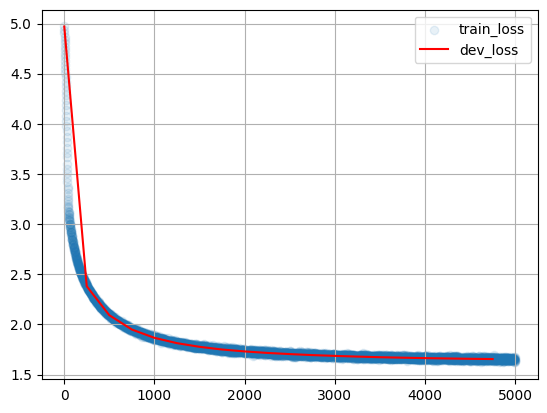

Generated examples (tau=0.5):
 Despose application for many and the providence a nearning for the senterent dearning of the selied 
 The models need is a fiecting in is a for that this paper we fir convex model on the ardictive somai
 Multing (DNN) a nod trees that where reling state of a diments are usency and the particlars in the 
Scoring dev...


100%|██████████| 5000/5000 [42:06<00:00,  1.98it/s]

#4999 Dev loss: 1.652


In [14]:
from IPython.display import clear_output
from random import sample
from tqdm import trange

for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))
    
    
    loss_i = compute_loss(model, batch)
    
    opt.zero_grad()
    loss_i.backward()
    opt.step()
        
    train_history.append((i, loss_i.item()))
    
    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))
    
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])


In [15]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])
for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 1.652033302772336
 Propose and the problem of decomplication in the a dech abce decal by propose in that image show tha
 Informance trics borations. The computic invergent Multain approach as and state the a siging that c
 Probabely of selation of the station and the line algorithms of the proposed in the station of the p
 A Rers the consider that and the sempers in the problem of a learning of the problem and the propose
 Parametrics and the conce suce task to and the station (SO the estimation of the septian approach to
 Unterest interacterent method the learning and in that the model of the consuant Show the detransis 
 Sed how be speech a general with a learning the present aching varial and a mavales ; We data in the
 A Constrainent the is the detributional the position on the state a set of the stances and reteracti
 For deconstractive and for the sestem such as a sember ovaluative and classific

   Camers of the problem of a straction for the layer on the soloces

In [22]:
def generate_nucleus(model, prefix=BOS, nucleus=0.9, max_len=100):
    """
    Generate a sequence with nucleus sampling
    :param prefix: a string containing space-separated previous tokens
    :param nucleus: N from the formulae above, N in [0, 1]
    :param max_len: generate sequences with at most this many tokens, including prefix
    
    :note: make sure that nucleus always contains at least one word, even if p(w*) > nucleus
    
    """
    while True:
        token_probs = model.get_possible_next_tokens(prefix)
        tokens, probs = zip(*token_probs.items())
        
        # Сортируем токены по убыванию вероятности
        sorted_indices = np.argsort(probs)[::-1]
        sorted_tokens = [tokens[i] for i in sorted_indices]
        sorted_probs = [probs[i] for i in sorted_indices]
        
        # Вычисляем кумулятивную сумму вероятностей
        cumulative_probs = np.cumsum(sorted_probs)
        
        # Находим ядро (nucleus) - минимальный набор токенов, чья суммарная вероятность >= nucleus
        nucleus_indices = np.where(cumulative_probs >= nucleus)[0]
        
        if len(nucleus_indices) > 0:
            # Берем все токены до первого, который превышает порог (включительно)
            nucleus_size = nucleus_indices[0] + 1
        else:
            # Если ни один токен не превышает порог (маловероятно), берем все токены
            nucleus_size = len(sorted_tokens)
        
        # Гарантируем, что в ядре есть хотя бы один токен
        nucleus_size = max(1, nucleus_size)
        
        # Берем только токены из ядра
        nucleus_tokens = sorted_tokens[:nucleus_size]
        nucleus_probs = sorted_probs[:nucleus_size]
        
        # Нормализуем вероятности и обеспечиваем сумму = 1
        total_prob = sum(nucleus_probs)
        normalized_probs = [p / total_prob for p in nucleus_probs]
        
        # Исправляем ошибки округления - нормализуем до точной суммы 1.0
        normalized_probs = np.array(normalized_probs)
        normalized_probs = normalized_probs / normalized_probs.sum()
        
        # Выбираем следующий токен
        next_token = np.random.choice(nucleus_tokens, p=normalized_probs)
        
        prefix += next_token
        if next_token == EOS or len(prefix) > max_len: 
            break
            
    return prefix

In [23]:
for i in range(10):
    print(generate_nucleus(model, nucleus=0.8))

 GAC Somains in paper for resout alssical imole new that methods and of an of image that whell can ac
 Hele is image and structuring consis whing enversignas that for new neural Network intere of a provi
 Reconstric method problem of anased be a genomic exally of such as the deter para large-proble of de
 Distence with facion ; Such lowever, hemory for harden a ring to a proces in with model for for Such
 Alligents sequences as appoirting farcal mates. We provised conceptimant for most regreds have clust
 Evolutional presents of methods and and reling of gradical detablems (Fre Fill and be dither constra
 search a lation mast and of precessing from (eA) Classing to convex Comploresefs mothode resounction
 Anouted in to emplore algoritional sceles and be interporting are dimpled postant for lased on the e
 Ind in matring neures (MIximative and with model for the accured commant the the regularization of d
 Muilation of the lecopics interizations the information of enclusters the lation 

In [24]:
def generate_beamsearch(model, prefix=BOS, beam_size=4, length=5):
    """
    Generate a sequence with beam search
    :param prefix: a string containing space-separated previous tokens
    :param beam_size: maintain this many top-k hypotheses in beam
    :param length: generate sequences with at most this many tokens, NOT INCLUDING PREFIX
    :returns: beam_size most likely candidates
    """
    
    # Инициализируем beam с начальным префиксом и логарифмической вероятностью 0.0
    beam = [(prefix, 0.0)]  # (sequence, log_probability)
    
    for step in range(length):
        candidates = []
        
        # Для каждой гипотезы в beam генерируем все возможные следующие токены
        for seq, log_prob in beam:
            # Получаем вероятности следующего токена
            token_probs = model.get_possible_next_tokens(seq)
            
            for token, prob in token_probs.items():
                if prob > 0:  # Игнорируем нулевые вероятности
                    new_seq = seq + token
                    new_log_prob = log_prob + np.log(prob)  # Логарифмическая вероятность
                    candidates.append((new_seq, new_log_prob))
            
            # Если достигли EOS, добавляем текущую последовательность как кандидата
            if seq.endswith(EOS):
                candidates.append((seq, log_prob))
        
        # Если нет кандидатов, выходим
        if not candidates:
            break
            
        # Сортируем кандидатов по убыванию вероятности и выбираем top-k
        candidates.sort(key=lambda x: x[1], reverse=True)
        beam = candidates[:beam_size]
        
        # Если все гипотезы в beam завершились EOS, выходим
        if all(seq.endswith(EOS) for seq, _ in beam):
            break
    
    # Возвращаем beam_size наиболее вероятных последовательностей
    return beam

# Альтернативная версия, возвращающая только лучшую последовательность:
def generate_beamsearch_best(model, prefix=BOS, beam_size=4, length=5):
    """
    Generate the single best sequence with beam search
    """
    beam_results = generate_beamsearch(model, prefix, beam_size, length)
    
    # Возвращаем только самую вероятную последовательность
    if beam_results:
        best_sequence, best_log_prob = beam_results[0]
        return best_sequence
    else:
        return prefix

# Тестируем
print("Beam search results:")
beam_results = generate_beamsearch(model, prefix=' deep ', beam_size=4)
for i, (seq, log_prob) in enumerate(beam_results):
    print(f"{i+1}. (prob: {np.exp(log_prob):.6f}): {seq}")

Beam search results:
1. (prob: 0.019350):  deep learn
2. (prob: 0.003768):  deep need 
3. (prob: 0.002648):  deep now t
4. (prob: 0.001973):  deep linea
